# Split the DMSO single cells per each plate into training and testing for plate specific modeling of type label

In [1]:
import pathlib
import random
import hashlib
import json
from functools import reduce

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

## Set paths, variables and Helpers

In [2]:
# Set random state for the whole notebook to ensure reproducibility
random_state = 0
random.seed(random_state)
np.random.seed(random_state)
k_fold_k = 5

# Path to directory with feature selected profiles
path_to_feature_selected_data = pathlib.Path().home() / "mnt" / "bandicoot" /\
    "CFReT_screening_data" / "screen_profiles"
if not path_to_feature_selected_data.exists() and\
    not path_to_feature_selected_data.is_dir():
    raise FileNotFoundError(
        f"Directory {path_to_feature_selected_data} does not exist or is not a directory."
    )

# Find all batch folders
batch_folders = list(path_to_feature_selected_data.glob("batch*"))
batch_folders = [folder for folder in batch_folders if folder.is_dir()]
if not batch_folders:
    raise FileNotFoundError(
        f"No batch folders found in {path_to_feature_selected_data}."
    )

# Make directory for split data
datasplit_dir = pathlib.Path(".") / "datasplits"
datasplit_dir.mkdir(exist_ok=True, parents=True)

In [3]:
def string_to_int_seed(s: str, n_bytes: int = 8) -> int:
    """
    Helper hashing plate identifier to seed/salt for reproducible and varied randomization of splits
    """
    digest = hashlib.sha256(s.encode("utf-8")).digest()
    return int.from_bytes(digest[:n_bytes], "big")

def salt_seed(seed: int, salt: int) -> int:
    """
    Helper for salting the global random state with plate specific salt
    """
    # Ensure the salted seed is within the range of valid seeds for random state
    return (seed + salt) % (2**32) 

def count_unique_well_combinations(df):
    """
    Dataset specific helper for validation
    """
    required_cols = ["Metadata_WellCol", "Metadata_WellRow"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    return df[required_cols].drop_duplicates().shape[0]

def table_metadata_cell_type_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Dataset specific helper for validation
    """
    if "Metadata_cell_type" not in df.columns:
        raise KeyError("Column 'Metadata_cell_type' not found in dataframe.")

    return (
        df["Metadata_cell_type"]
        .value_counts(dropna=False)
        .rename_axis("Metadata_cell_type")
        .reset_index(name="count")
    )

def check_no_mixed_cell_types(df: pd.DataFrame) -> pd.DataFrame | None:
    """
    Sanity check cell types are not mixed across wells such that datasplit
        holding out wells does not unexpectedly hold out cell types
    """
    required_cols = ["Metadata_WellRow", "Metadata_WellCol", "Metadata_cell_type"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns in df: {missing_cols}")

    well_type_counts = (
        df.groupby(["Metadata_WellRow", "Metadata_WellCol"])["Metadata_cell_type"]
        .nunique()
        .reset_index(name="n_cell_types")
    )

    mixed_wells = well_type_counts[well_type_counts["n_cell_types"] > 1]

    if mixed_wells.empty:
        return None
    
    else:
        mixed_well_details = (
            df.groupby(["Metadata_WellRow", "Metadata_WellCol"])["Metadata_cell_type"]
            .agg(lambda s: sorted(pd.unique(s)))
            .reset_index(name="cell_types")
            .merge(mixed_wells, on=["Metadata_WellRow", "Metadata_WellCol"], how="inner")
            .sort_values(["Metadata_WellRow", "Metadata_WellCol"])
        )
        return mixed_well_details    
    
def split_well_summary(df:pd.DataFrame, train_index:list, test_index:list) -> dict:
    """
    Helper for generating descriptive summary of well assignments across splits
        that is human readable and logged
    """
    summary = {}
    
    for split_name, split_index in zip(["train", "test"], [train_index, test_index]):
        
        summary[split_name] = {
            ct: list(wells)
            for ct, wells in (
                df.iloc[split_index].groupby(["Metadata_Well", "Metadata_cell_type"])
                .size()
                .reset_index(name="count")
            ).groupby("Metadata_cell_type")["Metadata_Well"] 
        }

    return summary

def stratified_fold_split(
    df: pd.DataFrame,
    group_col: str = 'Metadata_Well',
    class_col: str = 'Metadata_cell_type',
    random_state: int | None = None,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    Custom datasplit function because sklearn.StratifiedGroupFold does not 
    ensure representation of all classes when splitting across folds.
    
    This implementation produces k-fold split (more precisely k-fold heldout) 
        from the input dataset, with strictly 2 classes in the class label column
        and at least that many groups, keeping groups intact (not
        spanning across splits) while still ensuring representation. 
    """
    if random_state is not None:
        rng = np.random.default_rng(random_state)
    else:
        rng = np.random.default_rng()

    n_classes = df[class_col].nunique()
    if n_classes != 2:
        raise ValueError(f"Expected exactly 2 classes in {class_col}, got {n_classes}")

    n_groups = df[group_col].nunique()
    if n_groups < n_classes or n_groups <= 1:
        raise ValueError(
            f"Not enough groups in {group_col} for stratified splitting: "
            f"{n_groups} groups, {n_classes} classes"
        )

    n_splits = np.min(df.groupby(class_col)[group_col].nunique())

    pos_groups = df.loc[df[class_col] == type_counts_df.iloc[0][class_col], group_col].unique()
    neg_groups = df.loc[df[class_col] == type_counts_df.iloc[1][class_col], group_col].unique()
    
    # randomly and independently permute pos and neg groups for exactly n_split times
    pos_groups, neg_groups = sorted(pos_groups), sorted(neg_groups)
    rng.shuffle(pos_groups)
    rng.shuffle(neg_groups)
    
    train_group_splits, test_group_splits = [], []
    for fold_idx in range(n_splits):

        test_pos = pos_groups[fold_idx]
        test_neg = neg_groups[fold_idx]

        train_pos = [g for g in pos_groups if g != test_pos]
        train_neg = [g for g in neg_groups if g != test_neg]

        train_group_splits.append(train_pos + train_neg)
        test_group_splits.append([test_pos, test_neg])
        
    return [
        (
            df[df[group_col].isin(train_groups)].index.to_numpy(),
            df[df[group_col].isin(test_groups)].index.to_numpy(),
        )
        for train_groups, test_groups in zip(train_group_splits, test_group_splits)
    ]

## Datasplit EDA visualization

Processing batch: batch_1
	Processing CARD-CelIns-CX7_251210180001_sc_feature_selected for plate CARD-CelIns-CX7_251210180001.
	Processing CARD-CelIns-CX7_251203170001_sc_feature_selected for plate CARD-CelIns-CX7_251203170001.
	Processing CARD-CelIns-CX7_251205100001_sc_feature_selected for plate CARD-CelIns-CX7_251205100001.
	Processing CARD-CelIns-CX7_251208160001_sc_feature_selected for plate CARD-CelIns-CX7_251208160001.
	Processing CARD-CelIns-CX7_251212180001_sc_feature_selected for plate CARD-CelIns-CX7_251212180001.
	Processing CARD-CelIns-CX7_251211180001_sc_feature_selected for plate CARD-CelIns-CX7_251211180001.
	Processing CARD-CelIns-CX7_251212100001_sc_feature_selected for plate CARD-CelIns-CX7_251212100001.
	Processing CARD-CelIns-CX7_251213150001_sc_feature_selected for plate CARD-CelIns-CX7_251213150001.
	Processing CARD-CelIns-CX7_251201190001_sc_feature_selected for plate CARD-CelIns-CX7_251201190001.
	Processing CARD-CelIns-CX7_251201110001_sc_feature_selected for 

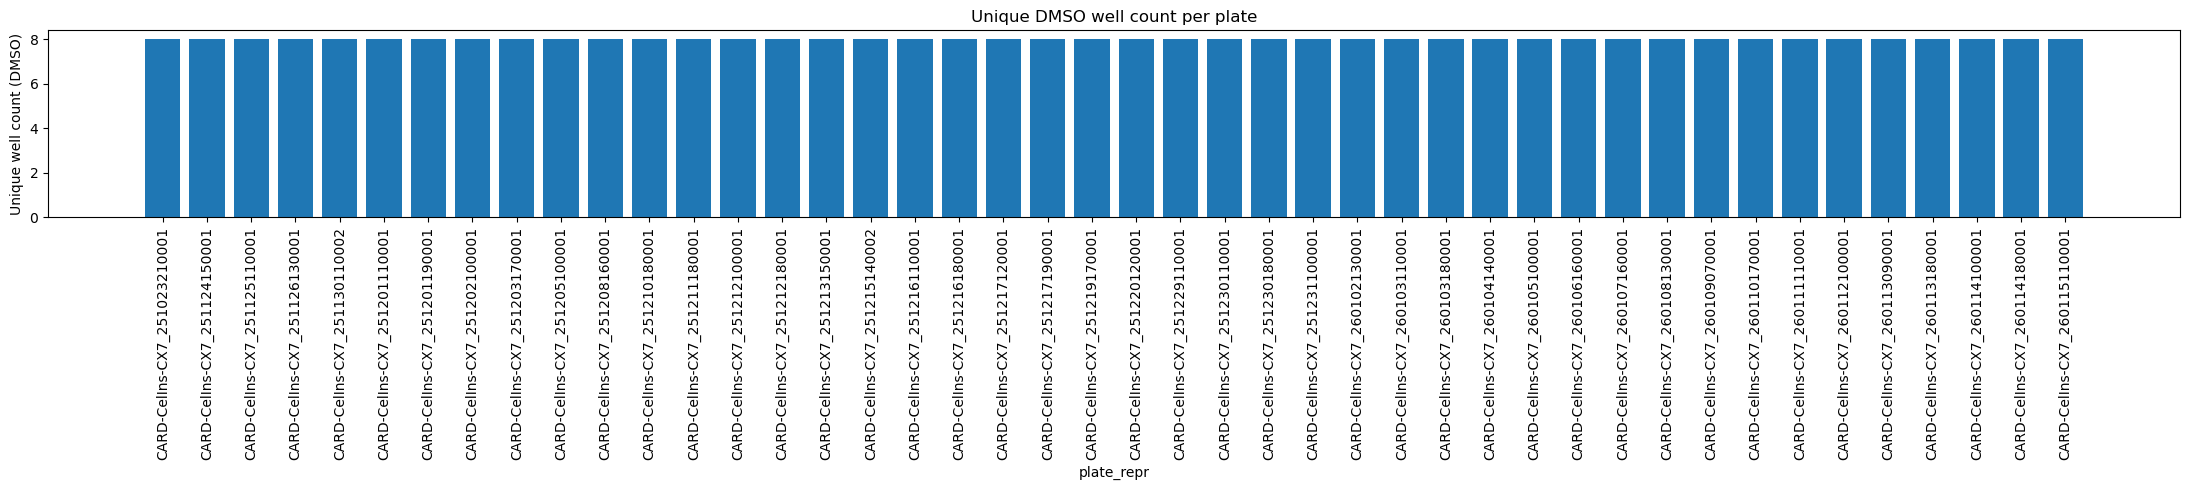

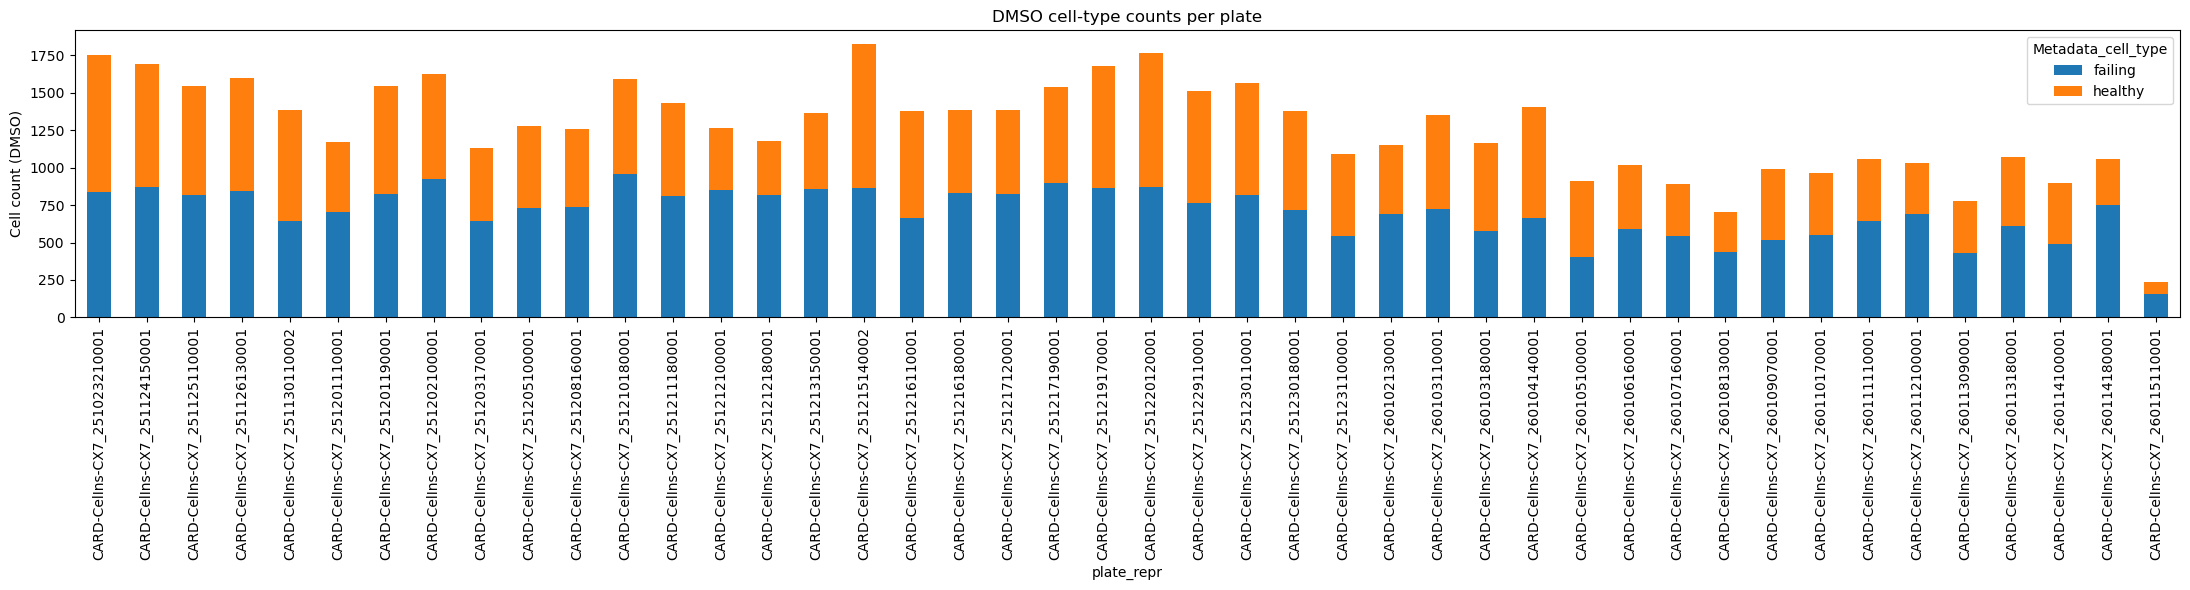

In [4]:
well_count_records = []
type_count_records = []

for batch_folder in batch_folders:
    print(f"Processing batch: {batch_folder.name}")

    feature_selected_files = list(
        batch_folder.rglob("**/single_cell_profiles/*_feature_selected.parquet")
    )

    if not feature_selected_files:
        print(f"\tNo profiles found in {batch_folder}. Skipping.")
        continue

    for file in feature_selected_files:
        plate_repr = "_".join(pathlib.Path(file).stem.split("_")[:2])
        print(f"\tProcessing {file.stem} for plate {plate_repr}.")

        try:
            # Lazily scan the parquet file to avoid loading all columns into memory
            lazy_df = pl.scan_parquet(file)
            
            # Get the schema to check for required columns
            columns = lazy_df.collect_schema().names()
            required_cols = ["Metadata_treatment", "Metadata_WellRow", "Metadata_WellCol", "Metadata_cell_type"]
            missing = [c for c in required_cols if c not in columns]
            
            if missing:
                print(f"\t\tMissing required column(s) for {plate_repr}: {missing}. Skipping.")
                continue

            # Lazily filter for DMSO rows
            dmso_lazy = lazy_df.filter(pl.col("Metadata_treatment") == "DMSO")

            # Execute a highly-optimized lazy query just for unique well combinations
            well_count = (
                dmso_lazy.select(["Metadata_WellRow", "Metadata_WellCol"])
                .unique()
                .select(pl.len())
                .collect(engine="cpu")
                .item()
            )

            if well_count == 0:
                print(f"\t\tNo DMSO rows for {plate_repr}. Skipping.")
                continue

            # Execute a separate lazy query just for grouping and counting cell types
            type_counts_df = (
                dmso_lazy.group_by("Metadata_cell_type")
                .agg(pl.len().alias("count"))
                .collect(engine="cpu")
                .to_pandas()
            )

        except Exception as e:
            print(f"\tError reading {file}: {e}. Skipping this file.")
            continue

        well_count_records.append(
            {"plate_repr": plate_repr, "well_count": well_count}
        )

        type_counts_df["plate_repr"] = plate_repr
        type_count_records.append(type_counts_df)

# ---- Tabulate + plot ----
well_count_df = pd.DataFrame(well_count_records).drop_duplicates("plate_repr")
well_count_df = well_count_df.sort_values("plate_repr").reset_index(drop=True)

type_count_df_long = pd.concat(type_count_records, ignore_index=True)
type_count_df_wide = (
    type_count_df_long
    .pivot_table(
        index="plate_repr",
        columns="Metadata_cell_type",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)
# Bar plot: well counts
plt.figure(figsize=(max(10, len(well_count_df) * 0.5), 5))
plt.bar(well_count_df["plate_repr"], well_count_df["well_count"])
plt.xticks(rotation=90)
plt.ylabel("Unique well count (DMSO)")
plt.xlabel("plate_repr")
plt.title("Unique DMSO well count per plate")
plt.tight_layout()
plt.show()

# Stacked bar plot: cell-type counts
ax = type_count_df_wide.plot(
    kind="bar",
    stacked=True,
    figsize=(max(10, len(type_count_df_wide) * 0.5), 6)
)
ax.set_xlabel("plate_repr")
ax.set_ylabel("Cell count (DMSO)")
ax.set_title("DMSO cell-type counts per plate")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Iterate over plate feature selected data, write fold datasplit indices along with DMSO subset

In [5]:
cell_type_classes = []
for batch_folder in batch_folders:

    print(f"Processing batch: {batch_folder.name}")

    feature_selected_files = list(
        batch_folder.glob("**/single_cell_profiles/*_feature_selected.parquet")
    )

    if not feature_selected_files:
        print(f"\tNo profiles found in {batch_folder}. Skipping.")
        continue

    for file in feature_selected_files:

        plate_repr = "_".join(pathlib.Path(file).stem.split("_")[:2])            
        plate_output_dir = datasplit_dir / plate_repr
        plate_output_dir.mkdir(exist_ok=True, parents=True)
        plate_name_salt: int = string_to_int_seed(plate_repr)
        salted_seed: int = salt_seed(random_state, plate_name_salt)

        try:
            DMSO_df = (
                pl.scan_parquet(file)
                .filter(pl.col("Metadata_treatment") == "DMSO")
                .collect(engine="cpu")
                .to_pandas()
            )
        except Exception as e:
            print(f"\tError reading/filtering {file.stem}: {e}. Skipping this file.")
            continue

        print(f"\tProcessing {file.stem} for plate {plate_repr}. ")

        if DMSO_df['Metadata_cell_type'].nunique() < 2:
            print(f"\t>Only one cell type present in {file.stem}. Skipping stratified split.")
            continue

        cell_type_classes.extend(DMSO_df["Metadata_cell_type"].unique())

        split = stratified_fold_split(
            DMSO_df, 
            group_col="Metadata_Well", 
            class_col="Metadata_cell_type", 
            random_state=salted_seed
        )

        for i, (train_index, test_index) in enumerate(split):
            fold_record = {
                "fold": i,
                "train_index": train_index.tolist(),
                "test_index": test_index.tolist(),
                "seed": salted_seed
            }
            fold_record.update(split_well_summary(DMSO_df, train_index, test_index))
            fold_documentation_path = plate_output_dir / f"fold_{i}_split.json"
            with open(fold_documentation_path, "w") as f:
                json.dump(fold_record, f, indent=4)

        print("\t>Datasplits written.")
        
        DMSO_df.to_parquet(plate_output_dir / "DMSO.parquet", index=False)
        print(f"\t>DMSO profiles written for {plate_repr}.")

Processing batch: batch_1
	Processing CARD-CelIns-CX7_251210180001_sc_feature_selected for plate CARD-CelIns-CX7_251210180001. 
	>Datasplits written.
	>DMSO profiles written for CARD-CelIns-CX7_251210180001.
	Processing CARD-CelIns-CX7_251203170001_sc_feature_selected for plate CARD-CelIns-CX7_251203170001. 
	>Datasplits written.
	>DMSO profiles written for CARD-CelIns-CX7_251203170001.
	Processing CARD-CelIns-CX7_251205100001_sc_feature_selected for plate CARD-CelIns-CX7_251205100001. 
	>Datasplits written.
	>DMSO profiles written for CARD-CelIns-CX7_251205100001.
	Processing CARD-CelIns-CX7_251208160001_sc_feature_selected for plate CARD-CelIns-CX7_251208160001. 
	>Datasplits written.
	>DMSO profiles written for CARD-CelIns-CX7_251208160001.
	Processing CARD-CelIns-CX7_251212180001_sc_feature_selected for plate CARD-CelIns-CX7_251212180001. 
	>Datasplits written.
	>DMSO profiles written for CARD-CelIns-CX7_251212180001.
	Processing CARD-CelIns-CX7_251211180001_sc_feature_selected for

## Save global encoding scheme from collected labels to ensure consistent model fitting and interpretation

In [6]:
unique_cell_types = sorted(set(cell_type_classes))

# define consistent encodings for downstream modeling
cell_type_encoding = {ct: i for i, ct in enumerate(unique_cell_types)}
print("Cell type encoding:")
for ct, enc in cell_type_encoding.items():
    print(f"\t{ct}: {enc}")

encoding_path = datasplit_dir / "cell_type_encoding.json"
with open(encoding_path, "w") as f:
    json.dump(cell_type_encoding, f)

Cell type encoding:
	failing: 0
	healthy: 1
